# Deep Learning: More Recurrent Neural Networks

In [1]:
import torch
import torch.nn as nn
import torchtext
from torchtext.legacy.data import Field, LabelField, BucketIterator
from torchtext.legacy.datasets import SST
from tqdm import tqdm
import matplotlib.pyplot as plt
torch.manual_seed(12)

print(f"Pytorch version: {torch.__version__}")
print(f"Torchtext version: {torchtext.__version__}")

/opt/anaconda3/envs/torchenv/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Pytorch version: 1.10.0
Torchtext version: 0.11.2



### Note: Python must be 3.11.x

If your kernel shows a value > 3.11.x you will need to downgrade. Please email the staff for help

In [2]:
# DEVICE CONFIGURATION
if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Using device:", device)

Using device: cpu


In [26]:
# Define field types
TEXT = Field(tokenize='basic_english', lower=True, include_lengths=True)
LABEL = LabelField(dtype=torch.float)

# Load SST data
train_data, _, test_data = SST.splits(
    TEXT, LABEL, fine_grained=True
)

In [27]:
# Display size of datasets
print("Train size:", len(train_data))
print("Test size:", len(test_data))

Train size: 8544
Test size: 2210


The `.splits` method is splitting up our dataset so that our train and test sets both have representative samples. 

The `fine_grained` parameter determines how many categories our data is broken into.
- if `True`: labels can be {'positive': 0, 'negative': 1, 'neutral': 2, 'very positive': 3, 'very negative': 4}
- if `False`: labels can be {'positive': 0, 'negative': 1, 'neutral': 2}

In [28]:
# Build vocabulary
MAX_VOCAB_SIZE = 10000
TEXT.build_vocab(train_data, max_size=MAX_VOCAB_SIZE)
LABEL.build_vocab(train_data)

vocab = TEXT.vocab.stoi
pad_idx = TEXT.vocab.stoi[TEXT.pad_token]

### Q: What variable type is `vocab`? What does the `.build_vocab` method do?
Hint: `.stoi` stand for "string to int"!

### A: 
Vocab is a dictionary variable type. 
.build_vocab builds the dictionary from the training data. 

In [29]:
def decode_dataset(dataset):
    # Reverse label mapping: string -> int
    label_stoi = LABEL.vocab.stoi
    texts = [example.text for example in dataset] 
    labels = [label_stoi[example.label] for example in dataset]
    return texts, labels

train_texts, train_labels = decode_dataset(train_data)
test_texts, test_labels   = decode_dataset(test_data)

### Sanity Check 🧠 
Let's check that the decoded dataset makes sense!

In [30]:
label_map = {idx: word for word, idx in LABEL.vocab.stoi.items()}

# Change i and see what happens!
i = 0

print(" ".join(test_texts[i]))
print(label_map[test_labels[i]])

effective but too-tepid biopic
neutral


----

Now let's define a `BucketIterator`:

In [31]:
BATCH_SIZE = 32
train_iterator, test_iterator = BucketIterator.splits(
    (train_data, test_data),
    batch_size=BATCH_SIZE,
    sort_within_batch=True,
    sort_key=lambda x: len(x.text),
    device=device
)

Below is a custom classifier:

In [32]:
# Custom LSTM Classifier
class SimpleLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=False)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, text, text_lengths):
        # text: [batch_size, seq_len] if batch_first=True
        embedded = self.embedding(text)  # [batch_size, seq_len, emb_dim]

        # Pack padded sequence
        packed_embedded = nn.utils.rnn.pack_padded_sequence(embedded, text_lengths.cpu(), batch_first=False, enforce_sorted=False)
        packed_output, (hidden, cell) = self.lstm(packed_embedded)

        # hidden: [1, batch_size, hidden_dim]  -> take the last hidden state
        return self.fc(hidden.squeeze(0))  # [batch_size, output_dim]

Here's a helper function so we can vary parameters later:

In [33]:
# TRAINING LOOP FUNCTION
def run_training_loop(num_epochs, random_state):
    # set random seed
    torch.manual_seed(random_state)

    EMBEDDING_DIM = 100
    HIDDEN_DIM = 256
    OUTPUT_DIM = 1

    # Send model to device
    model = SimpleLSTM(len(vocab), EMBEDDING_DIM, HIDDEN_DIM, OUTPUT_DIM, pad_idx).to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    # init output vars
    train_losses = []
    train_accs = []

    # train for num_epochs
    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0
        epoch_acc = 0

        # Wrap the iterator with tqdm
        for batch in tqdm(train_iterator, desc=f"Epoch {epoch+1}/{num_epochs}"):
            text, text_lengths = batch.text
            labels = batch.label

            text, text_lengths, labels = text.to(device), text_lengths.to(device), labels.to(device)

            optimizer.zero_grad()
            predictions = model(text, text_lengths).squeeze(1)

            # Loss
            loss = criterion(predictions, labels.float())
            loss.backward()
            optimizer.step()

            # Optional: compute accuracy
            preds = torch.round(torch.sigmoid(predictions))
            acc = (preds == labels).float().mean()
            epoch_loss += loss.item()
            epoch_acc += acc.item()
        
        avg_loss = epoch_loss/ len(train_iterator)
        avg_acc = epoch_acc/ len(train_iterator)
        train_losses.append(avg_loss)
        train_accs.append(avg_acc)
        print(f"Loss = {avg_loss:.4f}, Accuracy = {avg_acc:.4f}\n")
    return train_losses, train_accs, model

And another helper function plot the `train_losses` and `train_accs`:

In [34]:
def plot_training_performance(train_losses, train_accs, num_epochs, random_state):
    fig = plt.figure(figsize=(8,4), tight_layout=True)
    fig.suptitle(f"Model Training for State {random_state} over {num_epochs} Epochs")

    plt.subplot(1,2,1)
    plt.plot(train_losses, "-o", label="Train Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid()
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(train_accs, "-o", label="Train Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.grid()
    plt.legend()
    plt.show()


Let's train our model!

In [35]:
NUM_EPOCHS = 15
RANDOM_STATE = 42
train_losses, train_accs, model = run_training_loop(NUM_EPOCHS, RANDOM_STATE)

Epoch 1/15: 100%|██████████| 267/267 [00:09<00:00, 28.89it/s]


Loss = -23.7450, Accuracy = 0.2598



Epoch 2/15: 100%|██████████| 267/267 [00:09<00:00, 26.78it/s]


Loss = -64.1897, Accuracy = 0.2596



Epoch 3/15: 100%|██████████| 267/267 [00:08<00:00, 31.49it/s]


...

Loss = -492.0595, Accuracy = 0.2643



Epoch 14/15: 100%|██████████| 267/267 [00:08<00:00, 31.36it/s]


Loss = -534.7331, Accuracy = 0.2650



Epoch 15/15: 100%|██████████| 267/267 [00:08<00:00, 29.69it/s]

Loss = -574.0390, Accuracy = 0.2658



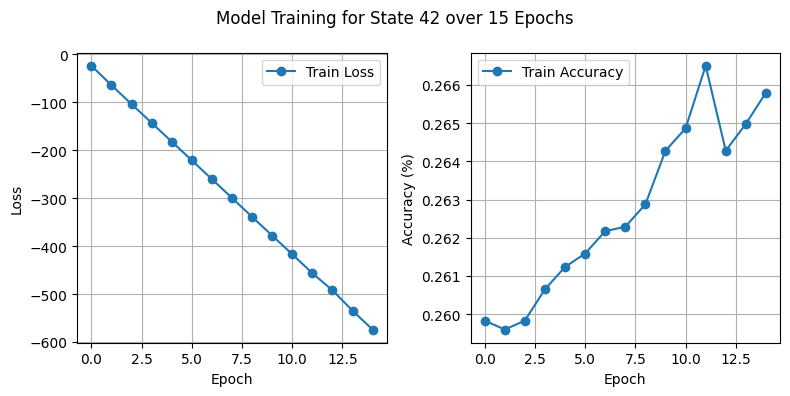

In [36]:
plot_training_performance(train_losses, train_accs, NUM_EPOCHS, RANDOM_STATE)

### Q: Try changing the value of `NUM_EPOCHS`. What happens to the train loss and accuracy plots? What does this tell us about the optimal number of training epochs?

### A: 
When NUM_EPOCHS increases, training loss decreases and training accuracy keep increasing. However, you have to be careful about overfitting. By using too many epochs, the model will get overfitted on the training data, and not perform as well on the testing data. This tells us that the optimal number of epochs is the most possible, without overfitting the model.

### Q: Try changing the value of `RANDOM_STATE`. What happens to the train loss and accuracy plots? What does this tell us about the impact of the initial guess (i.e. epoch 0)?

### A: 
Changing RANDOM_STATE changes the model's initial data order and weights, so the curves look different earlier on. This shows the initial guess affects speed or convergence and early learning, but. typically leads to similar results.

----

## Performance on the Test Set

Here's a helper function to run our model on the test data:

In [37]:

# Evaluate on test set
def run_evaluation_test():
    model.eval()
    test_loss, test_acc, = 0,0

    with torch.no_grad():
        for batch in test_iterator:
            text, text_lengths = batch.text
            labels = batch.label

            text = text.to(device)
            text_lengths = text_lengths.to(device)
            labels = labels.to(device)

            criterion = nn.BCEWithLogitsLoss()
            predictions = model(text, text_lengths).squeeze(1)
            loss = criterion(predictions, labels.float())

            preds = torch.round(torch.sigmoid(predictions))
            acc = (preds == labels).float().mean()

            test_loss += loss.item()
            test_acc += acc.item()

    return print(f"Test Accuracy: {100 * test_acc / len(test_iterator):.2f}%")


Finally, let's check that our model can generalize by processing the test data:

In [38]:
run_evaluation_test()

Test Accuracy: 28.21%


----
## Further Exploration 🔎

### Q: What happens to the **test** accuracy as `NUM_EPOCHS` is changed? What does this tell us about our neural network?
Note: remember to re-train your model before running on the test set!

### A:
Wheh NUM_EPOCHS is increased, the test accuracy typically gets higher until it plateaus. However, after that point, the accuracy decreases because the model is overfit.

### Q: What happens to the **test** accuracy as `RANDOM_STATE` is changed? What does this tell us about our neural network?
Note: remember to re-train your model before running on the test set!

### A:
The test accuracy changes slightly when RANDOM_STATE changes. This shows that our neural network is sensitive to randomness, so different starting points lead to similar but different results.

### Q: What happens to your results if you set `find_grained=True`?
Try to predict first and then test your hypothesis by changing the value and re-running the notebook!

### A: 
When find_grained is set to true, the task becomes harder. This causes accuracy to decrease, and loss to increase. In this case, it brought a 56% accuracy down to 28%.